# Serial Empirical Mode Decomposition (SEMD)

**Serial-EMD** speeds up multi-channel empirical mode decomposition by a
simple idea: instead of building multivariate envelopes (MEMD / BEMD),
**serialize** the channels into one long 1-D signal, run ordinary EMD, then
**split** the IMFs back.

$$
X \in \mathbb{R}^{N \times M}
\;\xrightarrow{\;\text{concatenate + bridge}\;}
x \in \mathbb{R}^{L}
\;\xrightarrow{\;\text{1-D EMD}\;}
\{\mathrm{IMF}_k\}
\;\xrightarrow{\;\text{deconcatenate}\;}
Y \in \mathbb{R}^{K \times M \times N}.
$$

with serialized length $L = MN + D(N-1)$ and transition width $D$.

**Reference**

> J. Zhang, F. Feng, P. Marti-Puig, C. F. Caiafa, Z. Sun, F. Duan, J. Solé-Casals.  
> *Serial-EMD: Fast Empirical Mode Decomposition Method for Multi-dimensional
Signals Based on Serialization.* Information Sciences, 2021.  
> https://doi.org/10.1016/j.ins.2021.09.033

This notebook uses the pure PySDKit implementation (`pysdkit.SEMD`) and does
**not** depend on Statsmodels / PyEMD.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "examples":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path and (ROOT / "pysdkit").exists():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SEMD, EMD
from pysdkit._emd.semd import concatenate_signals, transition_bridge
from pysdkit.data import test_multivariate_signal
from pysdkit.utils import get_timeline

print(SEMD())

Serial Empirical Mode Decomposition (SEMD)


## 2. Algorithm principles

### 2.1 Why serialization?

| Method | Envelope construction | Cost |
| --- | --- | --- |
| 1-D EMD | cubic splines on extrema | cheap |
| MEMD / MVEMD | project onto many directions, average envelopes | grows with channel count |
| BEMD | 2-D surface interpolation | very expensive |
| **SEMD** | reuse **any** 1-D EMD on a serialized series | near 1-D cost |

### 2.2 Transition bridge (the key detail)

A hard join $f(T) \neq g(0)$ creates a fake extremum.  During sifting the
**mean envelope** $m=(e_{\max}+e_{\min})/2$ then leaks into both channels.

SEMD inserts a bridge of length $D$ between channel $i$ and $i+1$:

$$
h = \mathrm{flip}(\mathrm{head}_{i+1})\odot a
+ \mathrm{flip}(\mathrm{tail}_{i})\odot \mathrm{flip}(a),
\qquad
a_j = \frac{j}{D+1},\; j=1,\ldots,D.
$$

Channels are then stacked head-to-tail with these bridges and column-major
vectorized.  After EMD, the bridge samples are discarded.

Paper default: $D \approx 0.2\,M$.

## 3. Build a small multi-channel toy signal

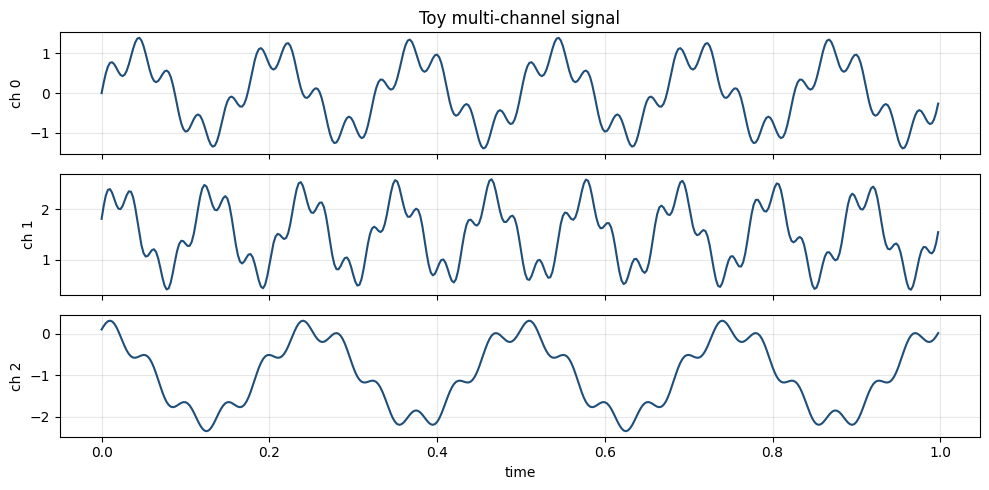

In [2]:
rng = np.random.default_rng(0)
M = 400
t = np.linspace(0, 1, M, endpoint=False)

ch0 = np.sin(2 * np.pi * 6 * t) + 0.4 * np.sin(2 * np.pi * 28 * t)
ch1 = 0.8 * np.sin(2 * np.pi * 9 * t + 0.4) + 0.3 * np.sin(2 * np.pi * 35 * t)
ch2 = 1.1 * np.cos(2 * np.pi * 4 * t) + 0.25 * np.sin(2 * np.pi * 22 * t)
# Add a level offset so hard joins are clearly discontinuous
ch1 = ch1 + 1.5
ch2 = ch2 - 1.0
signal = np.vstack([ch0, ch1, ch2])  # (N, M) PySDKit layout
N = signal.shape[0]
D = 50

fig, axes = plt.subplots(N, 1, figsize=(10, 5), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, signal[i], color="#1f4e79")
    ax.set_ylabel(f"ch {i}")
    ax.grid(True, alpha=0.3)
axes[0].set_title("Toy multi-channel signal")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

## 4. Visualize concatenation & the transition bridge

M=400, N=3, D=50 → serialized length L=1300 (= M*N + D*(N-1))


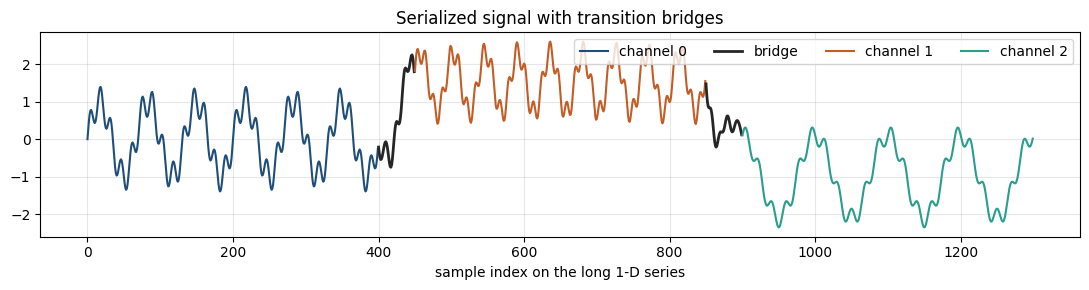

In [3]:
# Paper layout for concatenate: (M, N)
X = signal.T
serialized = concatenate_signals(X, D)
L = serialized.size
print(f"M={M}, N={N}, D={D} → serialized length L={L} (= M*N + D*(N-1))")

# Segment masks for plotting
colors = ["#1f4e79", "#c45c26", "#2a9d8f"]
fig, ax = plt.subplots(figsize=(11, 3))
cursor = 0
for i in range(N):
    ax.plot(np.arange(cursor, cursor + M), serialized[cursor : cursor + M], color=colors[i], label=f"channel {i}")
    cursor += M
    if i < N - 1:
        ax.plot(
            np.arange(cursor, cursor + D),
            serialized[cursor : cursor + D],
            color="0.15",
            lw=2,
            label="bridge" if i == 0 else None,
        )
        cursor += D
ax.set_title("Serialized signal with transition bridges")
ax.set_xlabel("sample index on the long 1-D series")
ax.legend(loc="upper right", ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

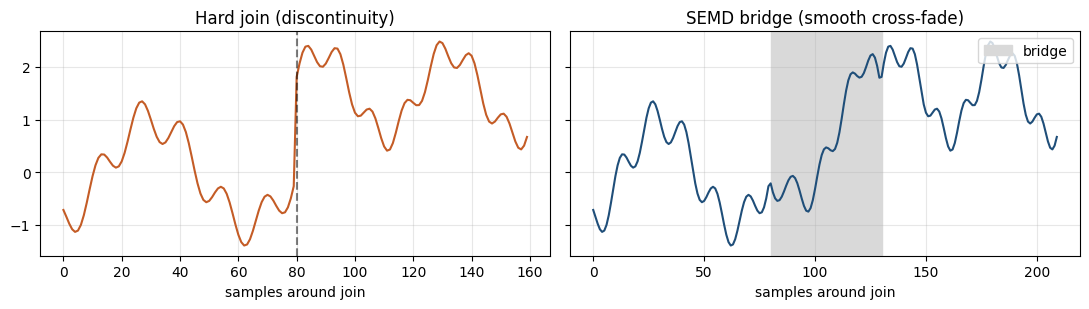

In [4]:
# Zoom on the first join: hard concat vs SEMD bridge
hard = np.concatenate([ch0, ch1])
bridge = transition_bridge(ch0[-D:], ch1[:D], num_interval=D)
soft_join = np.concatenate([ch0, bridge, ch1])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
w = 80
axes[0].plot(hard[M - w : M + w], color="#c45c26")
axes[0].axvline(w, color="k", ls="--", alpha=0.5)
axes[0].set_title("Hard join (discontinuity)")
axes[0].set_xlabel("samples around join")

axes[1].plot(soft_join[M - w : M + D + w], color="#1f4e79")
axes[1].axvspan(w, w + D, color="0.85", label="bridge")
axes[1].set_title("SEMD bridge (smooth cross-fade)")
axes[1].set_xlabel("samples around join")
axes[1].legend(loc="upper right")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Envelope spectrum at the join

EMD’s first sifting step builds cubic-spline **upper / lower envelopes** from
local extrema.  Below we compare those envelopes on a window centred at the
first channel join — with a hard concatenation versus with the SEMD bridge.

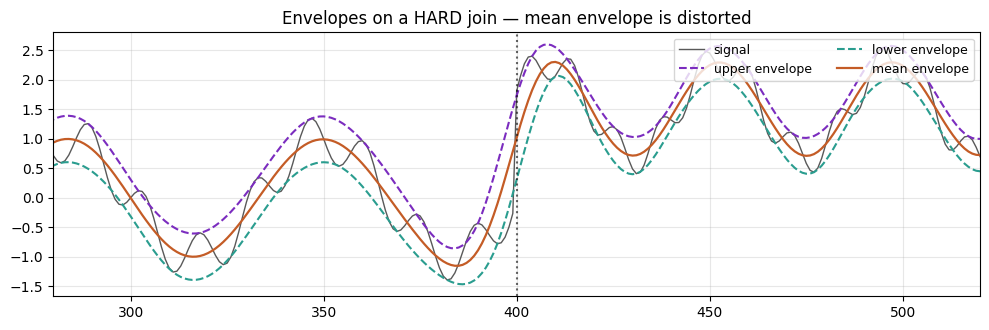

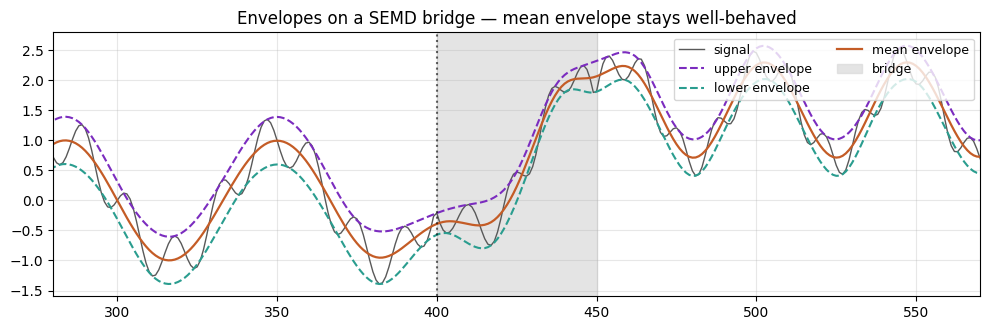

In [5]:
def local_envelopes(y: np.ndarray):
    """Upper / lower envelopes via the same spline routine used inside EMD."""
    emd = EMD()
    time = get_timeline(len(y), y.dtype)
    max_env, min_env, _, _ = emd.extract_max_min_spline(time, y)
    mean_env = 0.5 * (max_env + min_env)
    return max_env, min_env, mean_env


def plot_envelopes(y, join_index, title, bridge_span=None):
    max_env, min_env, mean_env = local_envelopes(y)
    idx = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(10, 3.4))
    ax.plot(idx, y, color="0.35", lw=1.0, label="signal")
    ax.plot(idx, max_env, color="#7b2cbf", ls="--", label="upper envelope")
    ax.plot(idx, min_env, color="#2a9d8f", ls="--", label="lower envelope")
    ax.plot(idx, mean_env, color="#c45c26", lw=1.6, label="mean envelope")
    ax.axvline(join_index, color="k", ls=":", alpha=0.6)
    if bridge_span is not None:
        a, b = bridge_span
        ax.axvspan(a, b, color="0.85", alpha=0.7, label="bridge")
    ax.set_title(title)
    ax.set_xlim(join_index - 120, join_index + 120 + (0 if bridge_span is None else D))
    ax.legend(loc="upper right", ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


plot_envelopes(hard, join_index=M, title="Envelopes on a HARD join — mean envelope is distorted")
plt.show()

plot_envelopes(
    soft_join,
    join_index=M,
    title="Envelopes on a SEMD bridge — mean envelope stays well-behaved",
    bridge_span=(M, M + D),
)
plt.show()

## 6. Run SEMD and inspect the decomposition

In [6]:
semd = SEMD(num_interval=D, max_imfs=4)
IMFs = semd.fit_transform(signal)  # (K, M, N)
print("IMFs shape:", IMFs.shape)
print("serialized length:", semd.serialized_signal.size)

recon = semd.reconstruct()
print("max |reconstruction error|:", np.max(np.abs(recon - signal)))

IMFs shape: (5, 400, 3)
serialized length: 1300
max |reconstruction error|: 2.220446049250313e-16


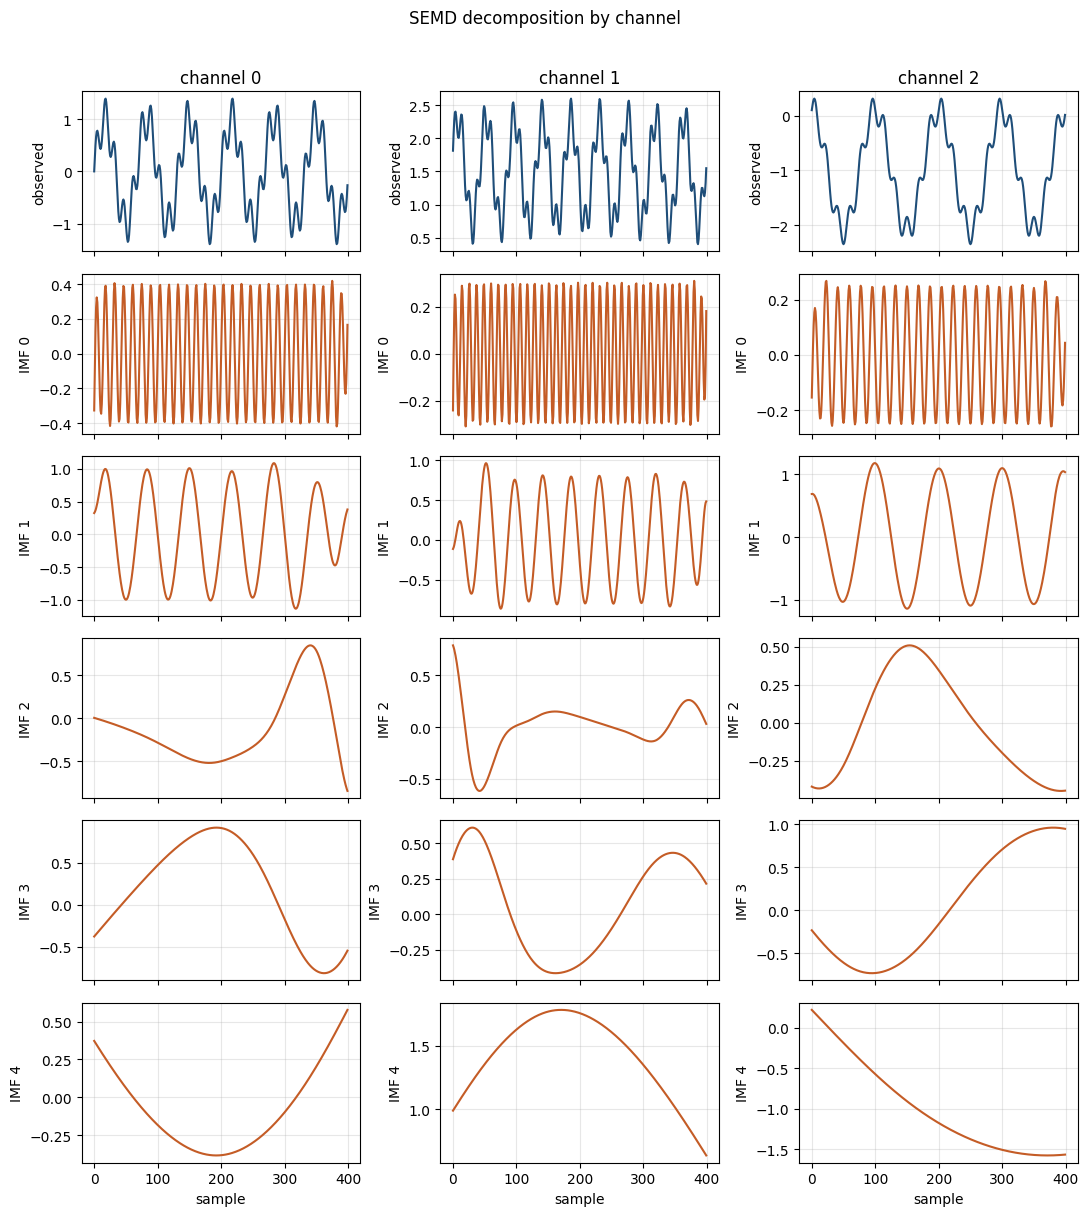

In [7]:
K = IMFs.shape[0]
fig, axes = plt.subplots(K + 1, N, figsize=(11, 2.0 * (K + 1)), sharex=True)
if N == 1:
    axes = np.asarray(axes).reshape(-1, 1)

for j in range(N):
    axes[0, j].plot(signal[j], color="#1f4e79")
    axes[0, j].set_title(f"channel {j}")
    axes[0, j].set_ylabel("observed")
    axes[0, j].grid(True, alpha=0.3)
    for k in range(K):
        axes[k + 1, j].plot(IMFs[k, :, j], color="#c45c26")
        axes[k + 1, j].set_ylabel(f"IMF {k}")
        axes[k + 1, j].grid(True, alpha=0.3)

for j in range(N):
    axes[-1, j].set_xlabel("sample")
fig.suptitle("SEMD decomposition by channel", y=1.01)
plt.tight_layout()
plt.show()

## 7. Built-in multivariate test signal

library multivariate shape: (2, 1000)


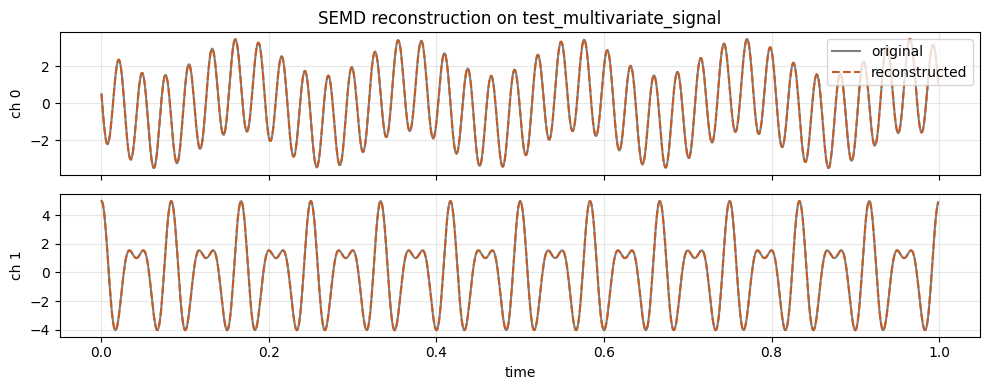

max |error|: 2.7755575615628914e-17


In [8]:
time, mv = test_multivariate_signal(case=1)
print("library multivariate shape:", mv.shape)

semd_lib = SEMD(interval_ratio=0.2, max_imfs=4)
IMFs_lib = semd_lib.fit_transform(mv)
recon_lib = semd_lib.reconstruct()

fig, axes = plt.subplots(mv.shape[0], 1, figsize=(10, 4), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(time, mv[i], color="0.5", label="original")
    ax.plot(time, recon_lib[i], color="#c45c26", ls="--", label="reconstructed")
    ax.set_ylabel(f"ch {i}")
    ax.grid(True, alpha=0.3)
axes[0].legend(loc="upper right")
axes[0].set_title("SEMD reconstruction on test_multivariate_signal")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

print("max |error|:", np.max(np.abs(recon_lib - mv)))

## 8. API summary

```python
from pysdkit import SEMD

semd = SEMD(num_interval=50, max_imfs=4)   # or interval_ratio=0.2
IMFs = semd.fit_transform(signal)          # signal: (N, M)
# IMFs shape: (K, M, N)
y_hat = semd.reconstruct()
```

Helpers for custom pipelines / plotting:

```python
from pysdkit._emd.semd import concatenate_signals, deconcatenate_imfs, transition_bridge
```

## 9. Takeaways

- SEMD = **concatenate (with bridges) → 1-D EMD → deconcatenate**.
- The bridge exists only to protect envelope estimation; it is removed from the final IMFs.
- Choose $D$ large enough to cover a few local oscillations (≈ 20% of $M$ works well).
- Any univariate EMD backend with a `fit_transform` API can be plugged in via `emd=`.